In [1]:
import sys
from pathlib import Path

here = Path().resolve()
root = next((p for p in (here, *here.parents) if (p / "sim").is_dir()), None)
if root is None:
    raise RuntimeError("Couldn't find project root (no sim/ folder in parents).")

# Put project root first so it wins over any installed package named 'sim'
sys.path.insert(0, str(root))

from sim.simulator import run_sim_and_report

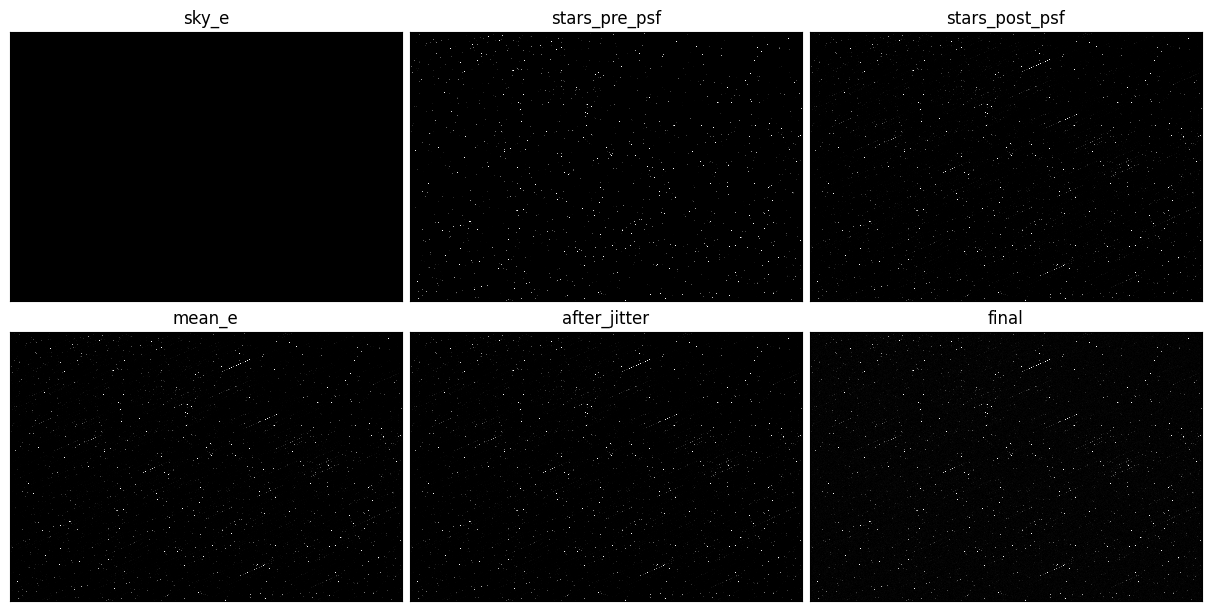

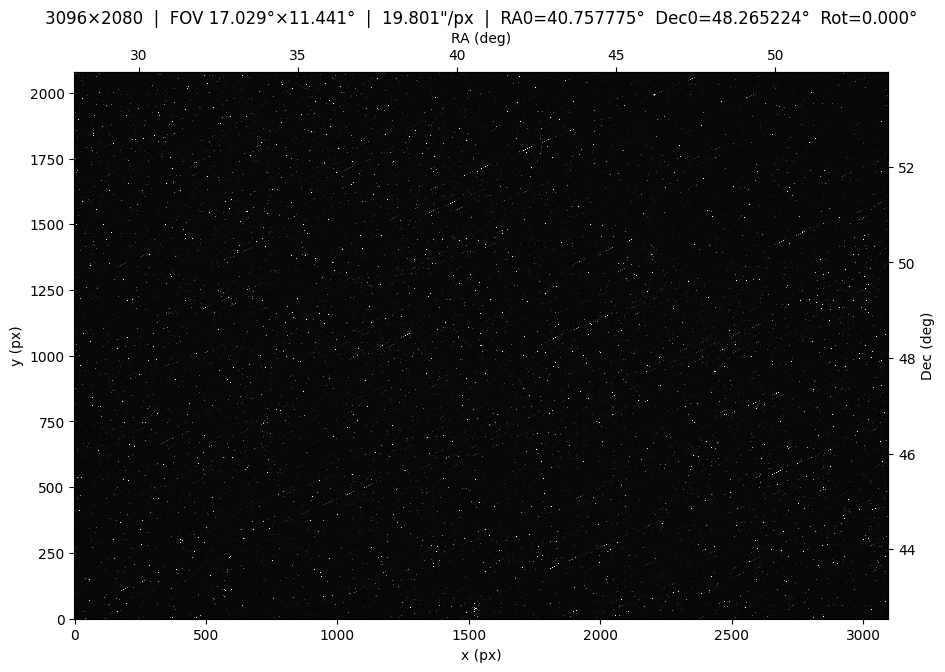

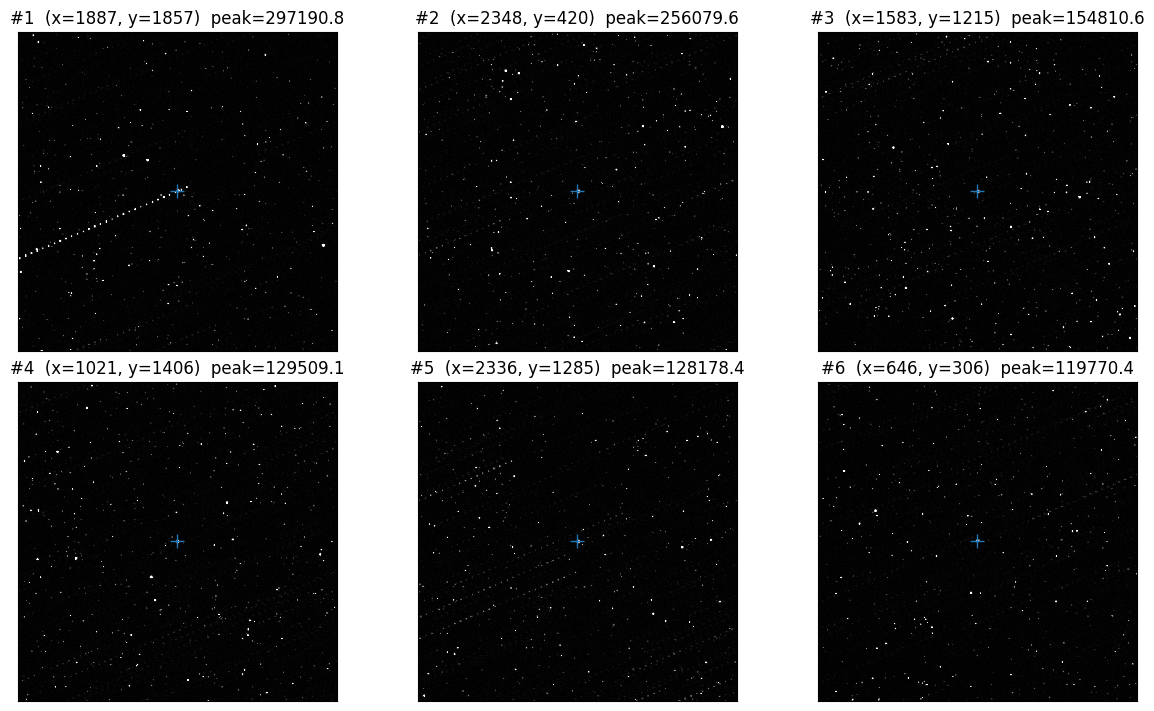

{'stages_png': 'out\\designrule_analytic_grating_fastlens\\stages.png', 'final_png': 'out\\designrule_analytic_grating_fastlens\\final.png', 'rois_png': 'out\\designrule_analytic_grating_fastlens\\rois.png', 'fits': 'out\\designrule_analytic_grating_fastlens\\designrule_analytic_grating_fastlens.fits', 'params_txt': 'out\\designrule_analytic_grating_fastlens\\params.txt'}


In [6]:
# ============================================================
# A) Recommended: Realistic groove densities with analytic grating
#    (lets you use ~300–600 l/mm without huge pupil sampling)
# ============================================================
frame, res, paths = run_sim_and_report(
    out_dir="out",
    run_name="designrule_analytic_grating_fastlens",
    stars_csv="sim/physics/starfields/field3.csv",
    overwrite=True,

    # --- Pointing ---
    ra0_deg=40.75777527,
    dec0_deg=48.26522428448249,
    rot_deg=0.0,

    # --- Camera (example: ASI178MM-like) ---
    cam_nx=3096,
    cam_ny=2080,
    cam_pixel_um=2.4,
    cam_read_noise_e=2.0,
    cam_gain_e_per_adu=1.0,
    cam_qe=0.6,

    # --- Lens: go fast (small f/#), moderate focal length ---
    # (keeps stars bright and reduces the N term in the design rule)
    lens_focal_mm=25.0,
    lens_f_number=1.4,
    lens_transmission=0.9,

    # --- Grating (use analytic to allow real line densities) ---
    mask_kind="grating",
    mask_grating_model="analytic",
    mask_angle_deg=23,
    mask_lines_per_mm=80.0,   # realistic class of off-the-shelf transmission gratings
    mask_duty_cycle=0.5,

    # Keep these moderate; analytic should not need extreme sampling
    mask_pupil_samples=512,
    mask_psf_size_px=513,
    mask_n_lambda=30,
    mask_aperture_diam_mm=None,

    # --- Exposure / band / sky ---
    exposure_s=5.0,
    sky_mu_mag_per_arcsec2=21.5,
    zeropoint_e_per_s=0.0,
    lambda_eff_nm=550.0,
    band_nm=300.0,

    # --- Blur/noise ---
    seeing_fwhm_arcsec=2.0,
    jitter_pointing_rms=5.0,   # (units as in your sim; keep consistent)
    enable_sky=True,
    enable_stars=True,
    enable_psf=True,
    enable_jitter=True,
    enable_noise=True,

    # --- Outputs ---
    show_plots=True,
    save_pngs=True,

    make_rois=True,
    roi_n=8,
    roi_half_size=220,
    roi_min_sep_px=180,
    roi_stretch="asinh",
)
print(paths)
